# Supervised Learning - Classification

## Importing Library Datasets

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [2]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
student_performance = fetch_ucirepo(id=53) 

# data (as pandas dataframes) 
X = student_performance.data.features 
y = student_performance.data.targets 

This is one of the earliest datasets used in the literature on classification methods and widely used in statistics and machine learning.  The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant.  One class is linearly separable from the other 2; the latter are not linearly separable from each other.

&nbsp;

## EDA

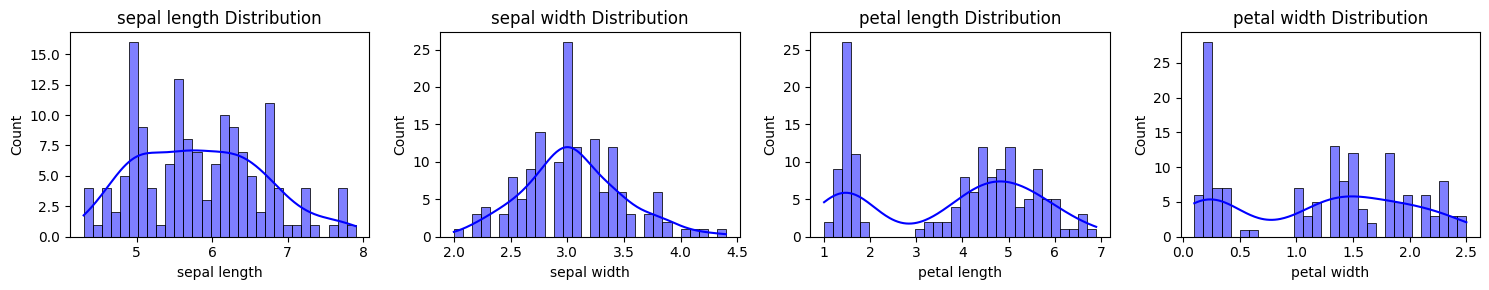

In [3]:
# Plotting data onto histogram to displays all features distribution
n_cols = len(X.columns)
n_display_cols = 4  # How many plots per row
n_rows = math.ceil(n_cols / n_display_cols)

num_features = X.select_dtypes(include=[np.number])
plt.figure(figsize=(15, 3 * n_rows))

for i, column in enumerate(num_features.columns, 1):
    plt.subplot(n_rows, n_display_cols, i)
    sns.histplot(X[column], bins=30, kde=True, color='blue')
    plt.title(f'{column} Distribution')
plt.tight_layout()
plt.show()

&nbsp;

In [4]:
# Visualizing Categorical Features Distribution (this datasets does not contain any categorical value, but still doin it for demonstration purpose)
cat_features = X.select_dtypes(include=[object, str])

nf_cols = len(X.columns)
nf_display_cols = 4  # How many plots per row
nf_rows = math.ceil(n_cols / n_display_cols)

plt.figure(figsize=(15, 3 * n_rows))
for i, column in enumerate(cat_features.columns, 1):
    plt.subplot(nf_rows, nf_display_cols, i)
    sns.countplot(y=X[column])
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

<Figure size 1500x300 with 0 Axes>

&nbsp;

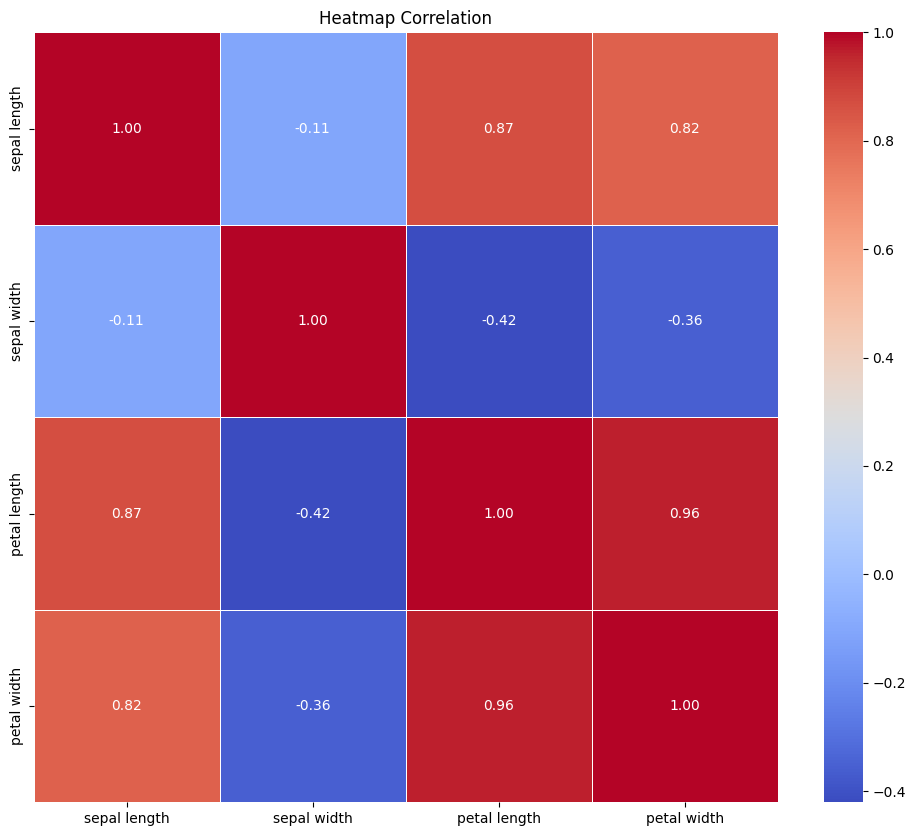

In [5]:
# Displaying Correlation Between Numerical Features Using Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Correlation')
plt.show()

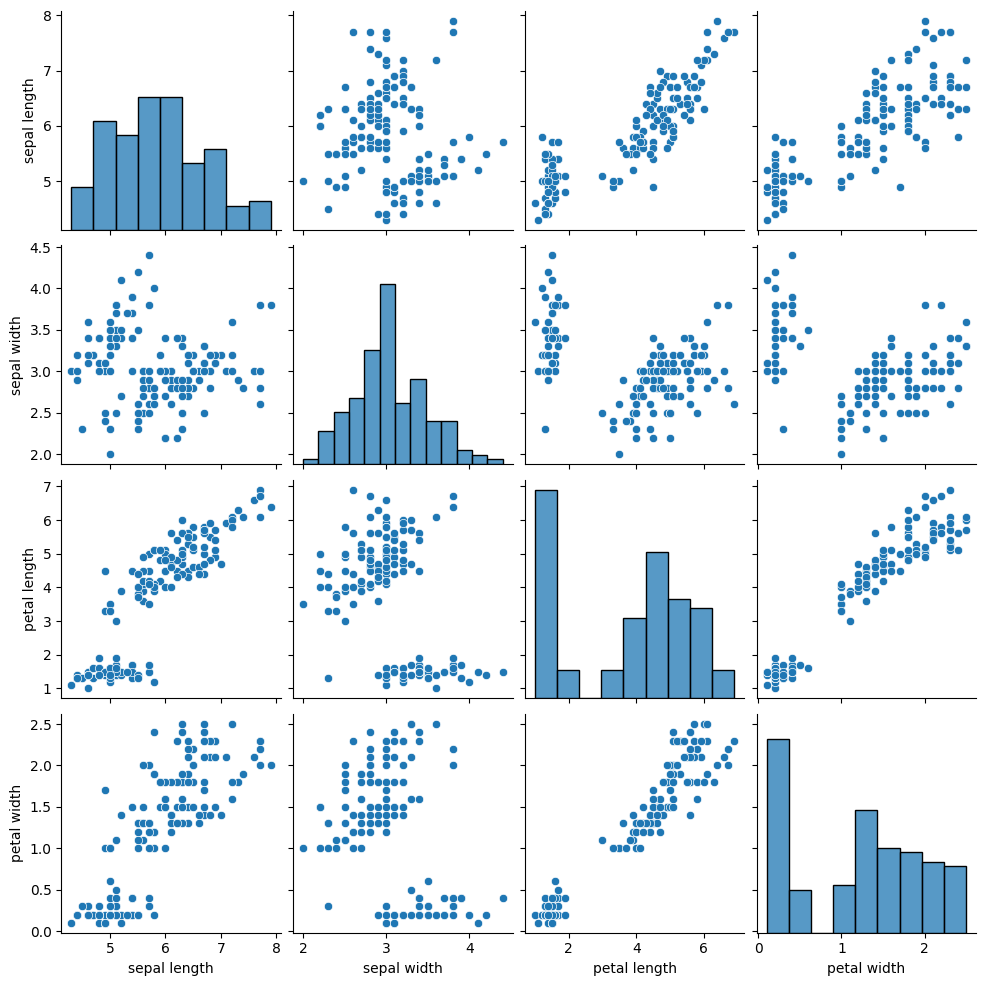

In [6]:
sns.pairplot(num_features)
plt.show()

&nbsp;

## Label Encoding

In [7]:
label_encoder = LabelEncoder()

categorical_columns = cat_features.columns

for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column])

X.head(10)

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


&nbsp;

## Data Splitting

In [12]:
scaler = MinMaxScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y.values.ravel(), test_size=0.2, random_state=42)

numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(120, 4), y_train=(120,)
Test set shape: X_test=(30, 4), y_test=(30,)


&nbsp;

## Model Training

All Classification Model Used Here From the SKlearn Library Which Is for Learning Purpose Only.

The classification model that use are: `KNeighborsClassifier`, `DecisionTreeClassifier`, `RandomForestClassifier`, `SVC`, and , `GaussianNB`

In [13]:
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)

&nbsp;

### Model Testing


In [15]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    results = {
        'Confusion Matrix': cm,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    }
    return results


results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test)
}

summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })

summary_df = pd.DataFrame(rows)

print(summary_df)

                          Model  Accuracy  Precision  Recall  F1-Score
0     K-Nearest Neighbors (KNN)       1.0        1.0     1.0       1.0
1            Decision Tree (DT)       1.0        1.0     1.0       1.0
2            Random Forest (RF)       1.0        1.0     1.0       1.0
3  Support Vector Machine (SVM)       1.0        1.0     1.0       1.0
4              Naive Bayes (NB)       1.0        1.0     1.0       1.0


&nbsp;

&nbsp;

**The results appear "perfectly odd" with all metrics showing 1.0 because the Iris dataset is a classic and relatively simple classification problem**